# 04 – Activation Functions



# 1. Why do we need activation functions?

A neuron first calculates a weighted sum:

`z = w1x1 + w2x2 + ... + b`

If we do not apply an activation function, the output remains a linear transformation.

### My understanding

An activation function introduces **non-linearity**.

This matters because real-world data usually contains relationships that cannot be represented well using only straight-line relationships.

### Real-world example

Image recognition is not simply a linear problem. A model may need to combine pixels into edges, shapes and objects.

### AI/ML usage

Activation functions help neural networks learn nonlinear patterns. They also affect gradient flow and therefore influence how the network learns during training.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

z = np.array([-3, -1, 0, 1, 3], dtype=float)
linear_output = 2 * z + 1

print("Input:", z)
print("Linear output:", linear_output)

Input: [-3. -1.  0.  1.  3.]
Linear output: [-5. -1.  1.  3.  7.]


### Result interpretation

The calculation changes the values but is still linear.

Adding nonlinear activation functions allows neural networks to represent more complex relationships.

# 2. Sigmoid

## Definition

The **sigmoid** function converts a number into a value between `0` and `1`.

### Formula

`sigmoid(z) = 1 / (1 + e^(-z))`

### Range

`0 < sigmoid(z) < 1`

### My understanding

I think of sigmoid as a smooth function that converts a score into a probability-like value.

- Large negative input → value close to `0`
- `z = 0` → `0.5`
- Large positive input → value close to `1`

### Real-world example

For binary classification, an output such as `0.90` can be interpreted as a high model probability for class `1`.

### AI/ML usage

Sigmoid is commonly used in the output layer of binary classification models.

### Advantages
- Output is bounded between 0 and 1.
- Smooth and differentiable.
- Useful for probability-like binary outputs.

### Limitations
- It saturates for very large positive or negative values.
- Its gradient becomes very small in saturated regions.

### Vanishing gradient

During backpropagation, gradients are used to update model parameters. When sigmoid is saturated, its derivative is very small. In deep networks, repeated small gradients can make learning difficult. This is one reason sigmoid is generally not the default hidden-layer activation in modern deep networks.

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

values = np.array([-5, -2, -1, 0, 1, 2, 5], dtype=float)

print("z values:", values)
print("Sigmoid values:", np.round(sigmoid(values), 4))

z values: [-5. -2. -1.  0.  1.  2.  5.]
Sigmoid values: [0.0067 0.1192 0.2689 0.5    0.7311 0.8808 0.9933]


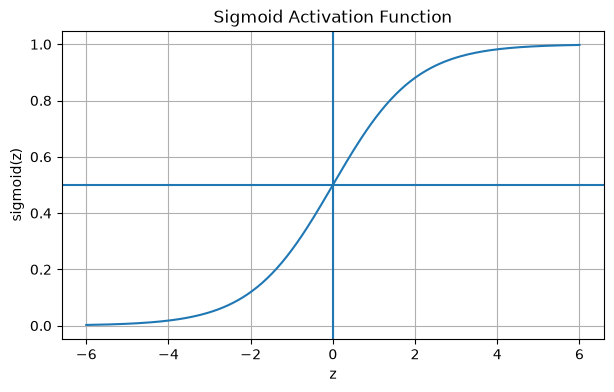

In [3]:
x_plot = np.linspace(-6, 6, 200)

plt.figure(figsize=(7, 4))
plt.plot(x_plot, sigmoid(x_plot))
plt.axhline(0.5)
plt.axvline(0)
plt.title("Sigmoid Activation Function")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.grid(True)
plt.show()

### Graph interpretation

The sigmoid graph is S-shaped.

The curve becomes almost flat at the two extremes. These saturated regions are related to the vanishing-gradient limitation.

# 3. Tanh

## Definition

**Tanh**, or hyperbolic tangent, maps values to a range between `-1` and `1`.

### Formula

`tanh(z) = (e^z - e^(-z)) / (e^z + e^(-z))`

### Range

`-1 < tanh(z) < 1`

### My understanding

Tanh is similar to sigmoid, but it is centered around zero.

- Negative input → negative output
- Zero input → zero output
- Positive input → positive output

### Real-world example

If a model needs to represent a signal that can point in a negative or positive direction, tanh naturally provides that range.

### AI/ML usage

Tanh has been used in hidden layers and recurrent neural networks. It can be useful when zero-centered activations are desirable.

### Advantages
- Zero-centered output.
- Smooth and differentiable.
- Represents both negative and positive values.

### Limitations
- Saturates for large positive and negative values.
- Can also contribute to vanishing gradients.

In [4]:
def tanh(z):
    return np.tanh(z)

values = np.array([-5, -2, -1, 0, 1, 2, 5], dtype=float)

print("z values:", values)
print("Tanh values:", np.round(tanh(values), 4))

z values: [-5. -2. -1.  0.  1.  2.  5.]
Tanh values: [-0.9999 -0.964  -0.7616  0.      0.7616  0.964   0.9999]


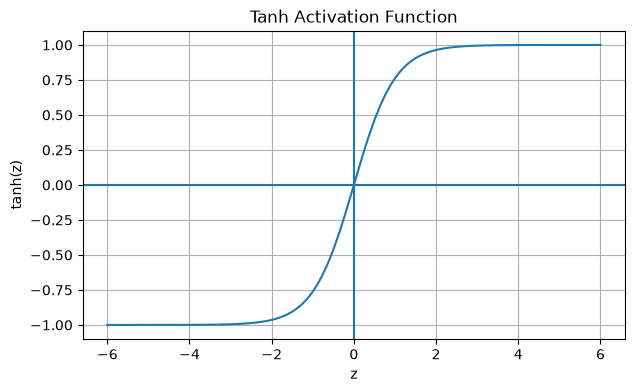

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(x_plot, tanh(x_plot))
plt.axhline(0)
plt.axvline(0)
plt.title("Tanh Activation Function")
plt.xlabel("z")
plt.ylabel("tanh(z)")
plt.grid(True)
plt.show()

### Graph interpretation

Tanh is also S-shaped, but unlike sigmoid it is centered around zero and ranges from approximately `-1` to `1`.

# 4. ReLU

## Definition

**ReLU** means **Rectified Linear Unit**.

### Formula

`ReLU(z) = max(0, z)`

So:
- Negative input → `0`
- Positive input → input itself

### My understanding

ReLU blocks negative values and lets positive values pass through.

### Real-world analogy

It is like a gate that blocks negative signals but allows positive signals to continue.

### Real-world example

In image models, hidden neurons can respond strongly to useful visual features. ReLU keeps positive responses and removes negative responses.

### AI/ML usage

ReLU is a very common activation for hidden layers in deep neural networks.

### Why did ReLU become popular?

- Very simple calculation.
- Positive-side gradient does not saturate like sigmoid/tanh.
- Often makes optimization of deep networks easier.

### Dying ReLU problem

For negative inputs, ReLU outputs zero and its gradient is zero. If a neuron stays in this region, it may stop receiving useful updates. This is called the **dying ReLU** problem.

In [6]:
def relu(z):
    return np.maximum(0, z)

values = np.array([-3, -1, 0, 1, 3], dtype=float)

print("z values:", values)
print("ReLU values:", relu(values))

z values: [-3. -1.  0.  1.  3.]
ReLU values: [0. 0. 0. 1. 3.]


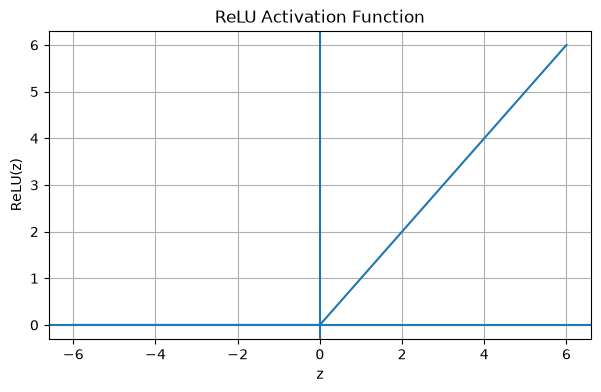

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(x_plot, relu(x_plot))
plt.axhline(0)
plt.axvline(0)
plt.title("ReLU Activation Function")
plt.xlabel("z")
plt.ylabel("ReLU(z)")
plt.grid(True)
plt.show()

### Graph interpretation

For negative inputs the output is zero.

For positive inputs the graph follows a straight line. This simple behavior is one reason ReLU is efficient and widely used.

# 5. Leaky ReLU

## Definition

**Leaky ReLU** is a variation of ReLU that keeps a small negative slope.

### Formula

`LeakyReLU(z) = z` when `z >= 0`

`LeakyReLU(z) = alpha × z` when `z < 0`

For example, `alpha = 0.01`.

### My understanding

ReLU completely blocks the negative side. Leaky ReLU leaves a small path for negative values.

### Real-world analogy

ReLU is like a door completely closed for negative signals. Leaky ReLU leaves the door slightly open.

### AI/ML usage

Leaky ReLU can be used in hidden layers when we want to reduce the risk of neurons becoming inactive because of the zero-gradient region of standard ReLU.

### Difference from ReLU

| ReLU | Leaky ReLU |
|---|---|
| Negative input becomes 0 | Negative input becomes a small negative value |
| Negative-side gradient is 0 | Negative-side gradient is small |
| Can have dying ReLU issue | Reduces the risk |

In [8]:
def leaky_relu(z, alpha=0.01):
    return np.where(z >= 0, z, alpha * z)

values = np.array([-3, -1, 0, 1, 3], dtype=float)

print("z values:", values)
print("Leaky ReLU values:", leaky_relu(values))

z values: [-3. -1.  0.  1.  3.]
Leaky ReLU values: [-0.03 -0.01  0.    1.    3.  ]


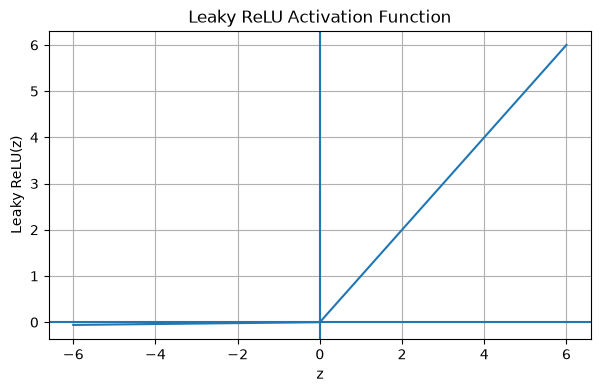

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(x_plot, leaky_relu(x_plot))
plt.axhline(0)
plt.axvline(0)
plt.title("Leaky ReLU Activation Function")
plt.xlabel("z")
plt.ylabel("Leaky ReLU(z)")
plt.grid(True)
plt.show()

### Graph interpretation

The negative side is no longer completely flat. A small slope allows negative inputs to retain a small gradient.

# 6. Softmax

## Definition

**Softmax** converts multiple raw class scores into values that form a probability distribution.

### Formula

`softmax(z_i) = e^(z_i) / sum(e^(z_j))`

### Properties

- Each output is between `0` and `1`.
- All outputs add up to `1`.

### My understanding

Softmax compares several class scores and converts them into relative probabilities.

### Real-world example

Suppose an image model predicts:

- Cat
- Dog
- Bird

It can produce three raw scores and softmax can convert them into three probability-like values.

### AI/ML usage

Softmax is commonly used in the output layer for **multi-class classification** where the classes are mutually exclusive.

Examples:
- Digit classification from 0 to 9
- Animal classification
- Product category classification

### Important distinction

**Sigmoid:** commonly used for binary classification or independent multi-label outputs.

**Softmax:** commonly used when choosing among mutually exclusive classes.

In [10]:
def softmax(z):
    exp_values = np.exp(z - np.max(z))
    return exp_values / np.sum(exp_values)

scores = np.array([2.0, 1.0, 0.1])
probabilities = softmax(scores)

print("Raw scores:", scores)
print("Softmax probabilities:", np.round(probabilities, 4))
print("Probability sum:", probabilities.sum())

Raw scores: [2.  1.  0.1]
Softmax probabilities: [0.659  0.2424 0.0986]
Probability sum: 1.0


### Result interpretation

The probabilities add up to `1`.

The class with the largest raw score receives the largest softmax probability.

Subtracting the maximum score before exponentiation is a numerical-stability technique. It avoids unnecessarily large exponential values without changing the final softmax probabilities.

# 7. Comparing the activation functions

| Function | Range | Common use | Main strength | Main limitation |
|---|---|---|---|---|
| Sigmoid | 0 to 1 | Binary output | Probability-like output | Vanishing gradients |
| Tanh | -1 to 1 | Some hidden/recurrent layers | Zero-centered | Vanishing gradients |
| ReLU | 0 to infinity | Hidden layers | Simple and efficient | Dying ReLU |
| Leaky ReLU | Small negative to infinity | Hidden layers | Keeps negative-side gradient | Requires a slope choice |
| Softmax | 0 to 1, sum = 1 | Multi-class output | Probability distribution | Mainly for class-score outputs |

### My understanding

There is no single activation function that is appropriate for every location in every neural network.

The choice depends on the task and the layer.

# 8. Using the supplied Online Retail dataset

I am connecting the activation-function concepts to the supplied dataset.

The dataset contains transaction-level information such as:
- `Quantity`
- `UnitPrice`
- `CustomerID`
- invoice information

For a simple demonstration, I will use `Quantity` and `UnitPrice` as two numerical inputs.

This is an educational example. I am not building a production business model.

In [11]:
df = pd.read_csv(r"/mnt/data/data(1).csv", encoding="latin1")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df[["Quantity", "UnitPrice"]].head())

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/data(1).csv'

In [ ]:
data = df[["Quantity", "UnitPrice"]].dropna().copy()
X = data.to_numpy(dtype=float)

feature_mean = X.mean(axis=0)
feature_std = X.std(axis=0)

X_scaled = (X - feature_mean) / np.where(feature_std == 0, 1, feature_std)

print("Cleaned shape:", X.shape)
print("First five standardized rows:")
print(np.round(X_scaled[:5], 3))

### Dataset preparation result

I selected two numerical features and removed missing rows.

I then standardized the features so that the two columns are on comparable scales. This makes the following neuron-style calculation easier to understand.

# 9. Applying activation functions to real dataset values

A simple neuron first calculates:

`z = w1x1 + w2x2 + b`

Then it applies an activation function.

I will use manually chosen weights only for learning the mechanics.

In [ ]:
weights = np.array([0.7, -0.4])
bias = 0.1

z_values = np.dot(X_scaled[:10], weights) + bias

print("First 10 weighted sums:")
print(np.round(z_values, 3))

In [ ]:
activation_results = pd.DataFrame({
    "z": z_values,
    "sigmoid": sigmoid(z_values),
    "tanh": tanh(z_values),
    "relu": relu(z_values),
    "leaky_relu": leaky_relu(z_values)
})

display(activation_results.round(4))

### Result interpretation

The same weighted sums are passed through different activation functions.

- **Sigmoid** compresses each score into `0–1`.
- **Tanh** compresses each score into `-1–1`.
- **ReLU** changes negative values to `0`.
- **Leaky ReLU** keeps a small negative value for negative scores.

This demonstrates why the activation function changes the behavior of a neural network even when the weighted sum is the same.

# 10. Softmax with a classification example

Softmax works with several class scores at the same time.

Suppose a model produces three scores:

`[2.0, 1.0, 0.1]`

These can represent three mutually exclusive classes.

In [ ]:
class_scores = np.array([2.0, 1.0, 0.1])
class_probabilities = softmax(class_scores)

softmax_result = pd.DataFrame({
    "Class": ["Class A", "Class B", "Class C"],
    "Probability": class_probabilities
})

display(softmax_result.round(4))
print("Total probability:", round(class_probabilities.sum(), 4))

### Softmax result interpretation

The three outputs add up to `1`.

The largest input score receives the largest probability.

In a real neural network, these scores usually come from the final linear layer before softmax.

# 11. Sigmoid vs Softmax

This is an important review concept.

### Sigmoid

For one output:

`probability = sigmoid(z)`

Commonly used for binary classification.

### Softmax

For several class scores:

`probability_i = exp(z_i) / sum(exp(z_j))`

Commonly used for mutually exclusive multi-class classification.

### Simple way to remember

**Binary question:** "Class 1 or not?" → Sigmoid is commonly appropriate.

**Multi-class question:** "Class A, B or C?" → Softmax is commonly appropriate.

# 12. Activation functions and backpropagation

During training, neural networks use **backpropagation** to calculate gradients.

The activation function affects how those gradients flow.

### Sigmoid and Tanh

Their saturation regions can produce very small gradients, which can contribute to vanishing gradients.

### ReLU

For positive inputs, the derivative is `1`, which can help gradients pass more directly.

For negative inputs, the derivative is `0`, which is related to the dying ReLU problem.

### Leaky ReLU

It keeps a small negative-side slope, allowing some gradient to pass for negative inputs.

### My understanding

Activation functions do not only change the output. They also influence how a neural network learns.